In [80]:
import yfinance as yf

symbols = ['NVDA', 'META', 'AMZN','AAPL', 'GOOGL']

for symbol in symbols:
    stock = yf.Ticker(symbol)
    price = stock.info.get('currentPrice', 'N/A')
    print(f"{symbol}: ${price}")




NVDA: $182.48
META: $653.56
AMZN: $208.39
AAPL: $264.72
GOOGL: $306.52


In [81]:
from dotenv import load_dotenv
import os

# load .env from the notebook working directory
load_dotenv()
# check if the environment variable is loaded

True

In [82]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("google_genai:gemini-2.5-flash")
response = llm.invoke("What is the capital of France?")

In [83]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

class StockAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    

In [84]:
@tool
def get_current_stock_price(symbol: str) -> float:
    
    '''
    Returns the current stock price for the given symbol.
    symbol: The stock ticker symbol (e.g., 'AAPL' for Apple Inc.)
    return: Current stock price as a string. If the price is not available, returns 'N/A'.

    '''

    stock = yf.Ticker(symbol)
    price = stock.info.get('currentPrice', 'N/A')

    return price

@tool
def get_stock_info_time_period(symbol: str, period: str) -> str:

    '''
        Returns historical stock data for the given symbol and time period.
        period can be one of the following: '1d', '5d', '1mo', '3mo', '6mo', '1y', '2y', '5y', '10y', 'ytd', 'max'
    '''
    stock = yf.Ticker(symbol)
    hist = stock.history(period=period)
    if hist.empty:
        return f"No historical data available for {symbol} with period {period}."
    else:
        return f"Historical data for {symbol} over the last {period}:\n{hist}"


In [79]:
get_current_stock_price('AAPL')

264.72

In [85]:
tools = [get_current_stock_price, get_stock_info_time_period]
llm_with_tools = llm.bind_tools(tools)

In [86]:
def chatbot_response(state: StockAgentState) -> StockAgentState:
    # Get the last user message
    return {"messages": llm_with_tools.invoke(state["messages"])}

In [87]:
graph_builder = StateGraph(StockAgentState)

graph_builder.add_node("chatbot_response", chatbot_response)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "chatbot_response")
graph_builder.add_conditional_edges("chatbot_response", tools_condition)
graph_builder.add_edge("chatbot_response", END)


In [88]:
graph = graph_builder.compile()

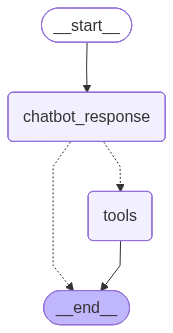

In [89]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))


In [90]:
prompt = [{"role": "user", "content": "What is the stock price of NVDA ?"}]
response = graph.invoke({"messages": prompt})
print("Chatbot response:", response["messages"][-1].content)

Chatbot response: 182.48


In [92]:
## Create a new conversation with multiple messages in the history
state = None
while True:
    user_input = input("User: ")
    if user_input.lower() == "exit":
        break

    if state is None:
        state = {"messages": [{"role": "user", "content": user_input}]}

    state["messages"].append({"role": "user", "content": user_input})
    state = graph.invoke(state)
    # The graph may return langchain message objects (e.g. AIMessage) which are not subscriptable.
    last = state["messages"][-1]
    if hasattr(last, 'content'):
        content = last.content
    elif isinstance(last, dict):
        content = last.get("content")
    else:
        content = str(last)
    print("Chatbot:", content)

Chatbot: Hello! How can I help you today?
Chatbot: 264.72
Chatbot: Historical data for AAPL over the last 5d:
                                 Open        High         Low       Close  \
Date                                                                        
2026-02-24 00:00:00-05:00  267.859985  274.890015  267.709991  272.140015   
2026-02-25 00:00:00-05:00  271.779999  274.940002  271.049988  274.230011   
2026-02-26 00:00:00-05:00  274.950012  276.109985  270.799988  272.950012   
2026-02-27 00:00:00-05:00  272.809998  272.809998  262.890015  264.179993   
2026-03-02 00:00:00-05:00  262.410004  266.529999  260.200012  264.720001   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-02-24 00:00:00-05:00  47014600        0.0           0.0  
2026-02-25 00:00:00-05:00  33714300        0.0           0.0  
2026-02-26 00:00:00-05:00  32345100        0.0           0.0  
2026-02-27 00:00:00-05:00  72366500